In [1]:
import os

In [2]:
from qiskit_aer.primitives import Estimator
from qiskit_aer import AerSimulator
import numpy as np
from qiskit.quantum_info import random_clifford, state_fidelity
from tomography import SelfGuidedTomography, Mean_Direct_Fidelity, NearSparseTomography, NearSparseTomography_v2

In [3]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

error_1 = depolarizing_error(1e-3, 1)
error_2 = depolarizing_error(5e-3, 2)

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(error_1, ['h', 's', 'sd', 'x'])
noise_model.add_all_qubit_quantum_error(error_2, ['cx'])

In [4]:
NQs = [2, 3, 4, 6]
L = len(NQs)
N = 100
shots = 1_000
num_iter = 15

simulator = Estimator(
    backend_options={
        'shots': shots,
        'method': "stabilizer",
        'noise_model': noise_model,
    },
    transpile_options={'optimization_level': 0},
)

In [5]:
from joblib import Parallel, delayed

def simulate(NQ, simulator=simulator):
    d = 2 ** NQ

    Omega = random_clifford(NQ).to_circuit()

    #####
    qasm = AerSimulator(method='density_matrix', noise_model=noise_model)
    Omega_density = Omega.copy()
    Omega_density.save_density_matrix()
    OmegaM_noisy = np.array(qasm.run(Omega_density).result().data()['density_matrix'])
    #####

    MDF = Mean_Direct_Fidelity(NQ)

    # purities  = []
    # stop_measuring_flag = [False]
    # def stop_measuring(MDF):
        
    #     if stop_measuring_flag[0]:
    #         return True
        
    #     purities.append(MDF.Purity)
    #     diffs = np.diff(purities[-3:])
        
    #     conditions = np.isclose(diffs, 0.0, atol=1e-5)
    #     if len(conditions) < 2:
    #         conditions = [False]
        
    #     all_conditions = np.all(conditions) and (MDF.Purity > 0.9)
        
    #     if all_conditions:
    #         stop_measuring_flag[0] = True
    #         print("Stopping measurement")
        
    #     return all_conditions
    def stop_measuring(MDF):
        return False

    def I_ex(x):
        return 1 - MDF.MeanFidelity(
            1,
            2 * NQ ** 2,
            x,
            Omega,
            simulator,
            truncation=None,
            stop_measuring=stop_measuring,
        )

    def I_th(x):
        x = x / np.linalg.norm(x)
        Is = []
        I_1 = 1 - np.vdot(x, OmegaM_noisy @ x)
        Is.append(I_1)

        F = 1 - I_ex(x)
        FF = np.max([np.min([(d * F - 1) / (d - 1), 1]), 0])

        rho_white = FF * np.outer(x, x.conj()) + (1 - FF) * np.eye(d) / d
        rho_white = 0.5 * rho_white + 0.5 * rho_white.T.conj()
        rho_white = rho_white / np.trace(rho_white)
        I_2 = 1 - state_fidelity(rho_white, OmegaM_noisy, validate=False)
        Is.append(I_2)

        rho = NearSparseTomography_v2(x, MDF=MDF)
        rho = 0.5 * rho + 0.5 * rho.T.conj()
        rho = rho / np.trace(rho)
        I_3 = 1 - state_fidelity(rho, OmegaM_noisy, validate=False)
        Is.append(I_3)

        return Is

    Fidelities = []
    Measures = []
    Last = []
    Purity = []

    def callback(i, x):
        Last.append(x)
        Fidelities.append(I_th(x))
        Measures.append(len(MDF.Measures))
        Purity.append(MDF.Purity)
        return None

    psi0 = np.random.rand(d) + 1j * np.random.rand(d)
    psi0 = psi0 / np.linalg.norm(psi0)
    guess = psi0

    def postprocessing(x):
        return NearSparseTomography(x, MDF=MDF)

    SelfGuidedTomography(
        I_ex,
        guess,
        num_iter=num_iter,
        callback=callback,
        postprocessing=postprocessing,
    )

    Results = [
        np.array(Fidelities),
        np.array(Measures),
        np.array(Last),
        np.array(Purity),
        OmegaM_noisy,
    ]

    return Results


In [6]:
# simulate(2)

In [7]:
iterator = np.repeat(NQs, N).flatten()

R = Parallel(n_jobs=-1, verbose=11)(delayed(simulate)(int(NQ)) for NQ in iterator)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 44 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:  

In [8]:
Fids, Meas, _, Pury = [[[R[i + j * N][r] for i in range(N)] for j in range(len(NQs))] for r in range(4)]

Fids = np.real(Fids)
Meas = np.array(Meas)

In [9]:
import matplotlib.pyplot as plt

In [10]:
4 ** np.array(NQs)

array([  16,   64,  256, 4096])

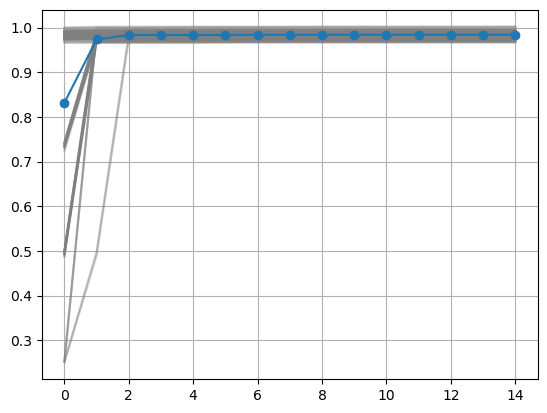

In [11]:
rep = 0

plt.plot(np.array(Pury[rep]).T, alpha=0.4, color='gray')
plt.plot(np.mean(Pury[rep], axis=0), '-o')
plt.grid()

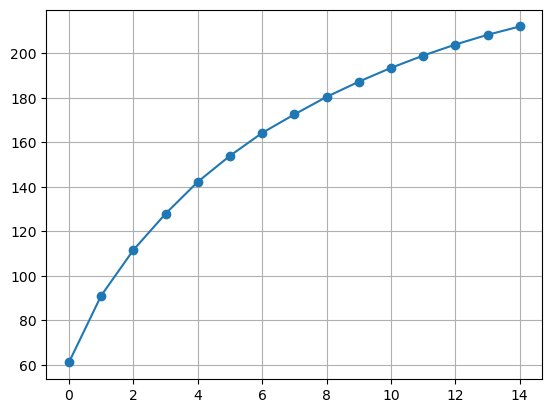

In [12]:
plt.plot(np.mean(Meas[2], axis=0), '-o')
plt.grid()

Text(0.5, 0, 'Iteration')

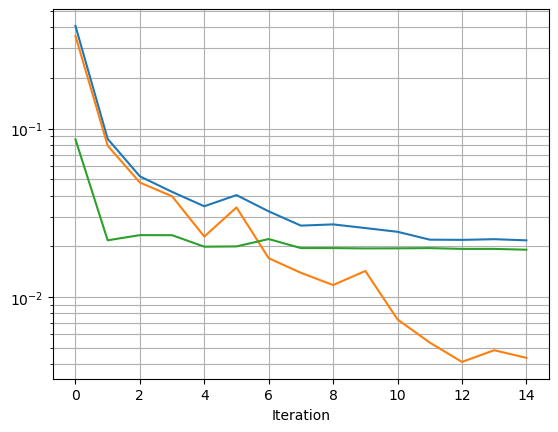

In [13]:
plt.semilogy(np.mean(Fids[-3], axis=0))
plt.grid(which='both')
plt.xlabel('Iteration')

In [14]:
# Save data. Ax order Fids and Meas are: [NQ, Nrun, Niter]

filename = "sgqt_for_mixed.npz"

data = {
    "N": [N],
    "shots": [shots],
    "Niter": [num_iter],
    "NQs": NQs,
    "Fids": Fids,
    "Meas": Meas,
    "info": [
        "N, shots, and Niter are single integers in one array each.",
        "NQs is the array of number of qubits.",
        "Fids and Meas have shapes (len(NQs), N, Niter)"
    ],
}

os.makedirs("data", exist_ok=True)

filepath = os.path.join("data", filename)
np.savez(filepath, **data)